Evaluate the Model on the Unrotated MNIST

In [ ]:
import tqdm
import torch
import numpy as np
import torchvision

from transformers import CLIPVisionModel, CLIPProcessor
from PIL import Image

# Load the model and processor
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
from transformers import CLIPModel
vision_model = CLIPVisionModel.from_pretrained('tanganke/clip-vit-base-patch32_mnist')
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.vision_model.load_state_dict(vision_model.vision_model.state_dict())
model.to(device)
preprocess = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load the datasets
training_set = torchvision.datasets.MNIST('./data', train=True, download=True, transform=torchvision.transforms.ToTensor())
validation_set = torchvision.datasets.MNIST('./data', train=False, download=True, transform=torchvision.transforms.ToTensor())

# Create data loaders
trainloader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=0)

model.eval()
# Define classes
classes = [str(i) for i in range(10)]

# Precompute text features for each class label
text_inputs = preprocess(text=classes, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = model.get_text_features(**text_inputs)

correct = 0
total = 0

for images, labels in tqdm.tqdm(testloader):
    labels = [classes[x] for x in labels]
    with torch.no_grad():
        # Convert grayscale images to RGB
        images_rgb = [Image.fromarray((image.squeeze().numpy() * 255).astype(np.uint8)).convert("RGB") for image in images]
        
        # Preprocess images within the loop
        image_inputs = preprocess(images=images_rgb, return_tensors="pt").to(device)
        image_features = model.get_image_features(**image_inputs)
        
        # Compute similarities between image features and text features
        similarities = image_features @ text_features.T
        probs = similarities.softmax(dim=-1).cpu().numpy()
    
    result = [classes[x] for x in np.argmax(probs, axis=1)]
    for pred, label in zip(result, labels):
        if pred == label:
            correct += 1

print(correct / len(testloader.dataset))

Evaluate the model on 90 degree rotations of the test set. 

In [ ]:
import tqdm
import torch
import numpy as np
import torchvision
import torchvision.transforms as transforms
import random
from transformers import CLIPVisionModel, CLIPProcessor
from PIL import Image

class RotatedDataset(torch.utils.data.Dataset):
    def __init__(self, original_dataset, angles):
        self.original_dataset = original_dataset
        self.angles = angles
        # self.transform = transforms.Compose([
        #     transforms.ToPILImage(),
        # ])

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        img, label = self.original_dataset[idx]
        angle = random.choice(self.angles)
        # rotated_img = self.transform(img).rotate(angle)
        # rotated_img = transforms.ToTensor()(rotated_img)
        rotated_img = rotate_tensor(img, angle)
        return rotated_img, label
    
def rotate_tensor(tensor, angle):
    # pil_image = transforms.ToPILImage()(tensor)
    # rotated_image = pil_image.rotate(angle)
    # return transforms.ToTensor()(rotated_image)
    return transforms.functional.rotate(tensor, angle)

def random_rotate_dataset(dataloader, angles=[0, 90, 180, 270]):
    original_dataset = dataloader.dataset
    rotated_dataset = RotatedDataset(original_dataset, angles)
    return torch.utils.data.DataLoader(rotated_dataset, batch_size=dataloader.batch_size, shuffle=False, num_workers=0, pin_memory=True)

# Load the model and processor
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
from transformers import CLIPModel
vision_model = CLIPVisionModel.from_pretrained('tanganke/clip-vit-base-patch32_mnist')
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.vision_model.load_state_dict(vision_model.vision_model.state_dict())
model.to(device)
preprocess = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load the datasets
training_set = torchvision.datasets.MNIST('./data', train=True, download=True, transform=torchvision.transforms.ToTensor())
validation_set = torchvision.datasets.MNIST('./data', train=False, download=True, transform=torchvision.transforms.ToTensor())

# Create data loaders
trainloader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=0)
testloader = random_rotate_dataset(testloader)

model.eval()
# Define classes
classes = [str(i) for i in range(10)]

# Precompute text features for each class label
text_inputs = preprocess(text=classes, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = model.get_text_features(**text_inputs)

correct = 0
total = 0

for images, labels in tqdm.tqdm(testloader):
    labels = [classes[x] for x in labels]
    with torch.no_grad():
        # Convert grayscale images to RGB
        images_rgb = [Image.fromarray((image.squeeze().numpy() * 255).astype(np.uint8)).convert("RGB") for image in images]
        
        # Preprocess images within the loop
        image_inputs = preprocess(images=images_rgb, return_tensors="pt").to(device)
        image_features = model.get_image_features(**image_inputs)
        
        # Compute similarities between image features and text features
        similarities = image_features @ text_features.T
        probs = similarities.softmax(dim=-1).cpu().numpy()
    
    result = [classes[x] for x in np.argmax(probs, axis=1)]
    for pred, label in zip(result, labels):
        if pred == label:
            correct += 1

print(correct / len(testloader.dataset))

Evaluate Model on random rotations (0-360) of the test set. 

In [ ]:
# download the dataset
!wget -nc http://www.iro.umontreal.ca/~lisa/icml2007data/mnist_rotation_new.zip
# uncompress the zip file
!unzip -n mnist_rotation_new.zip -d mnist_rotation_new

In [ ]:
import tqdm
import torch
import numpy as np
import torchvision
import torchvision.transforms as transforms
import random
from src import datasets
from transformers import CLIPVisionModel, CLIPProcessor
from PIL import Image

# Load the model and processor
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
from transformers import CLIPModel
vision_model = CLIPVisionModel.from_pretrained('tanganke/clip-vit-base-patch32_mnist')
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.vision_model.load_state_dict(vision_model.vision_model.state_dict())
model.to(device)
preprocess = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load the datasets
training_set, validation_set = datasets.get_datasets("rotated_mnist", greyscale = False, image_size=None)

# Create data loaders
trainloader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=0)


model.eval()
# Define classes
classes = [str(i) for i in range(10)]

# Precompute text features for each class label
text_inputs = preprocess(text=classes, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = model.get_text_features(**text_inputs)

correct = 0
total = 0

for images, labels in tqdm.tqdm(testloader):
    labels = [classes[x] for x in labels]
    with torch.no_grad():
        # Convert grayscale images to RGB
        images_rgb = [Image.fromarray((image.squeeze().numpy() * 255).astype(np.uint8)).convert("RGB") for image in images]
        
        # Preprocess images within the loop
        image_inputs = preprocess(images=images_rgb, return_tensors="pt").to(device)
        image_features = model.get_image_features(**image_inputs)
        
        # Compute similarities between image features and text features
        similarities = image_features @ text_features.T
        probs = similarities.softmax(dim=-1).cpu().numpy()
    
    result = [classes[x] for x in np.argmax(probs, axis=1)]
    for pred, label in zip(result, labels):
        if pred == label:
            correct += 1

print(correct / len(testloader.dataset))

Summarize VIT model. 

In [ ]:
from torchinfo import summary

# Print the summary of the vision model
summary(model.vision_model, input_size=(1, 3, 224, 224), device=str(device))

Evaluate group averaged model on regular MNIST

In [ ]:
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from transformers import CLIPVisionModel, CLIPModel, CLIPProcessor
from PIL import Image
import numpy as np
import torchvision
from tqdm import tqdm

# Load the model and processor
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
vision_model = CLIPVisionModel.from_pretrained('tanganke/clip-vit-base-patch32_mnist')
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.vision_model.load_state_dict(vision_model.vision_model.state_dict())
model.to(device)
preprocess = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Define a rotation function
def rotate_tensor(tensor, angle):
    return TF.rotate(tensor, angle)

# Load the datasets
training_set = torchvision.datasets.MNIST('./data', train=True, download=True, transform=torchvision.transforms.ToTensor())
validation_set = torchvision.datasets.MNIST('./data', train=False, download=True, transform=torchvision.transforms.ToTensor())

# Create data loaders
trainloader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=0)

# Define classes
classes = [str(i) for i in range(10)]

# Precompute text features for each class label
text_inputs = preprocess(text=classes, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = model.get_text_features(**text_inputs)

correct = 0
total = 0
angles = [0, 90, 180, 270]
model.eval()
for images, labels in tqdm(testloader):

    labels = [classes[x] for x in labels]
    
    with torch.no_grad():
        # Convert grayscale images to RGB and apply rotation
        images_rgb = [Image.fromarray((image.squeeze().numpy() * 255).astype(np.uint8)).convert("RGB") for image in images]

        # Initialize a tensor to accumulate rotated outputs
        accumulated_outputs = None

        for angle in angles:
            # Apply rotation
            rotated_images_rgb = [rotate_tensor(image, angle) for image in images_rgb]
        
            # Preprocess images within the loop
            image_inputs = preprocess(images=rotated_images_rgb, return_tensors="pt").to(device)
        
            # Pass the rotated inputs through the convolutional layer
            conv_outputs = model.vision_model.embeddings.patch_embedding(image_inputs['pixel_values'])
            
            # Rotate the outputs of the convolutional layer back
            #conv_outputs = conv_outputs.permute(0, 2, 3, 1)  # Change shape to [batch, height, width, channels]
            rotated_conv_outputs = torch.stack([rotate_tensor(output, -angle) for output in conv_outputs])
            #rotated_conv_outputs = rotated_conv_outputs.permute(0, 3, 1, 2)  # Change shape back to [batch, channels, height, width]

            # Accumulate the rotated outputs
            if accumulated_outputs is None:
                accumulated_outputs = rotated_conv_outputs
            else:
                accumulated_outputs += rotated_conv_outputs

        # Average the accumulated outputs
        averaged_outputs = accumulated_outputs / len(angles)
        
        # Flatten the spatial dimensions and add position embeddings
        batch_size, num_channels, height, width = averaged_outputs.shape
        num_patches = height * width
        averaged_outputs = averaged_outputs.view(batch_size, num_channels, num_patches).permute(0, 2, 1)  # Shape [batch, num_patches, channels]
        
        # Add position embeddings
        position_ids = torch.arange(num_patches, dtype=torch.long, device=device).unsqueeze(0).expand(batch_size, -1)
        position_embeddings = model.vision_model.embeddings.position_embedding(position_ids)
        averaged_outputs += position_embeddings
        
        # Continue with the rest of the model
        outputs = model.vision_model.pre_layrnorm(averaged_outputs)
        encoder_outputs = model.vision_model.encoder(inputs_embeds=outputs)
        outputs = encoder_outputs.last_hidden_state
        outputs = model.vision_model.post_layernorm(outputs)

        # Use the last_hidden_state for classification
        image_features = outputs[:, 0, :]  # Use the [CLS] token representation
        
        # Ensure the dimensions match the expected input dimensions for text_projection
        if image_features.shape[-1] != model.text_projection.in_features:
            image_features = torch.nn.Linear(image_features.shape[-1], model.text_projection.in_features).to(device)(image_features)
        
        similarities = image_features @ text_features.T
        probs = similarities.softmax(dim=-1).cpu().numpy()
    
    result = [classes[x] for x in np.argmax(probs, axis=1)]
    for pred, label in zip(result, labels):
        if pred == label:
            correct += 1

print(correct / len(testloader.dataset))

Evaluate the group averaged model on random 90 degree rotations

In [ ]:
import torch
import numpy as np
import torchvision
import torchvision.transforms as transforms
import random
from transformers import CLIPVisionModel, CLIPProcessor
from PIL import Image
from tqdm import tqdm

class RotatedDataset(torch.utils.data.Dataset):
    def __init__(self, original_dataset, angles):
        self.original_dataset = original_dataset
        self.angles = angles
        # self.transform = transforms.Compose([
        #     transforms.ToPILImage(),
        # ])

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        img, label = self.original_dataset[idx]
        angle = random.choice(self.angles)
        # rotated_img = self.transform(img).rotate(angle)
        # rotated_img = transforms.ToTensor()(rotated_img)
        rotated_img = rotate_tensor(img, angle)
        return rotated_img, label
    
def rotate_tensor(tensor, angle):
    # pil_image = transforms.ToPILImage()(tensor)
    # rotated_image = pil_image.rotate(angle)
    # return transforms.ToTensor()(rotated_image)
    return transforms.functional.rotate(tensor, angle)

def random_rotate_dataset(dataloader, angles=[0, 90, 180, 270]):
    original_dataset = dataloader.dataset
    rotated_dataset = RotatedDataset(original_dataset, angles)
    return torch.utils.data.DataLoader(rotated_dataset, batch_size=dataloader.batch_size, shuffle=False, num_workers=0, pin_memory=True)

# Load the model and processor
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
from transformers import CLIPModel
vision_model = CLIPVisionModel.from_pretrained('tanganke/clip-vit-base-patch32_mnist')
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.vision_model.load_state_dict(vision_model.vision_model.state_dict())
model.to(device)
preprocess = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load the datasets
training_set = torchvision.datasets.MNIST('./data', train=True, download=True, transform=torchvision.transforms.ToTensor())
validation_set = torchvision.datasets.MNIST('./data', train=False, download=True, transform=torchvision.transforms.ToTensor())

# Create data loaders
trainloader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=0)
testloader = random_rotate_dataset(testloader)

# Define classes
classes = [str(i) for i in range(10)]

# Precompute text features for each class label
text_inputs = preprocess(text=classes, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = model.get_text_features(**text_inputs)

correct = 0
total = 0
angles = [0, 90, 180, 270]
model.eval()
for images, labels in tqdm(testloader):

    labels = [classes[x] for x in labels]
    
    with torch.no_grad():
        # Convert grayscale images to RGB and apply rotation
        images_rgb = [Image.fromarray((image.squeeze().numpy() * 255).astype(np.uint8)).convert("RGB") for image in images]

        # Initialize a tensor to accumulate rotated outputs
        accumulated_outputs = None

        for angle in angles:
            # Apply rotation
            rotated_images_rgb = [rotate_tensor(image, angle) for image in images_rgb]
        
            # Preprocess images within the loop
            image_inputs = preprocess(images=rotated_images_rgb, return_tensors="pt").to(device)
        
            # Pass the rotated inputs through the convolutional layer
            conv_outputs = model.vision_model.embeddings.patch_embedding(image_inputs['pixel_values'])
            
            # Rotate the outputs of the convolutional layer back
            #conv_outputs = conv_outputs.permute(0, 2, 3, 1)  # Change shape to [batch, height, width, channels]
            rotated_conv_outputs = torch.stack([rotate_tensor(output, -angle) for output in conv_outputs])
            #rotated_conv_outputs = rotated_conv_outputs.permute(0, 3, 1, 2)  # Change shape back to [batch, channels, height, width]

            # Accumulate the rotated outputs
            if accumulated_outputs is None:
                accumulated_outputs = rotated_conv_outputs
            else:
                accumulated_outputs += rotated_conv_outputs

        # Average the accumulated outputs
        averaged_outputs = accumulated_outputs / len(angles)
        
        # Flatten the spatial dimensions and add position embeddings
        batch_size, num_channels, height, width = averaged_outputs.shape
        num_patches = height * width
        averaged_outputs = averaged_outputs.view(batch_size, num_channels, num_patches).permute(0, 2, 1)  # Shape [batch, num_patches, channels]
        
        # Add position embeddings
        position_ids = torch.arange(num_patches, dtype=torch.long, device=device).unsqueeze(0).expand(batch_size, -1)
        position_embeddings = model.vision_model.embeddings.position_embedding(position_ids)
        averaged_outputs += position_embeddings
        
        # Continue with the rest of the model
        outputs = model.vision_model.pre_layrnorm(averaged_outputs)
        encoder_outputs = model.vision_model.encoder(inputs_embeds=outputs)
        outputs = encoder_outputs.last_hidden_state
        outputs = model.vision_model.post_layernorm(outputs)

        # Use the last_hidden_state for classification
        image_features = outputs[:, 0, :]  # Use the [CLS] token representation
        
        # Ensure the dimensions match the expected input dimensions for text_projection
        if image_features.shape[-1] != model.text_projection.in_features:
            image_features = torch.nn.Linear(image_features.shape[-1], model.text_projection.in_features).to(device)(image_features)
        
        similarities = image_features @ text_features.T
        probs = similarities.softmax(dim=-1).cpu().numpy()
    
    result = [classes[x] for x in np.argmax(probs, axis=1)]
    for pred, label in zip(result, labels):
        if pred == label:
            correct += 1

print(correct / len(testloader.dataset))

Evaluating group averaged model on random rotations (0-360)

In [ ]:
import torch
import numpy as np
import torchvision
import torchvision.transforms as transforms
import random
from src import datasets
from transformers import CLIPVisionModel, CLIPProcessor
from PIL import Image
from tqdm import tqdm

# Load the model and processor
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
from transformers import CLIPModel
vision_model = CLIPVisionModel.from_pretrained('tanganke/clip-vit-base-patch32_mnist')
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.vision_model.load_state_dict(vision_model.vision_model.state_dict())
model.to(device)
preprocess = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load the datasets
training_set, validation_set = datasets.get_datasets("rotated_mnist", greyscale = False, image_size=None)

# Create data loaders
trainloader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=0)

# Define classes
classes = [str(i) for i in range(10)]

# Precompute text features for each class label
text_inputs = preprocess(text=classes, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = model.get_text_features(**text_inputs)

correct = 0
total = 0
angles = [0, 90, 180, 270]
model.eval()
for images, labels in tqdm(testloader):

    labels = [classes[x] for x in labels]
    
    with torch.no_grad():
        # Convert grayscale images to RGB and apply rotation
        images_rgb = [Image.fromarray((image.squeeze().numpy() * 255).astype(np.uint8)).convert("RGB") for image in images]

        # Initialize a tensor to accumulate rotated outputs
        accumulated_outputs = None

        for angle in angles:
            # Apply rotation
            rotated_images_rgb = [rotate_tensor(image, angle) for image in images_rgb]
        
            # Preprocess images within the loop
            image_inputs = preprocess(images=rotated_images_rgb, return_tensors="pt").to(device)
        
            # Pass the rotated inputs through the convolutional layer
            conv_outputs = model.vision_model.embeddings.patch_embedding(image_inputs['pixel_values'])
            
            # Rotate the outputs of the convolutional layer back
            #conv_outputs = conv_outputs.permute(0, 2, 3, 1)  # Change shape to [batch, height, width, channels]
            rotated_conv_outputs = torch.stack([rotate_tensor(output, -angle) for output in conv_outputs])
            #rotated_conv_outputs = rotated_conv_outputs.permute(0, 3, 1, 2)  # Change shape back to [batch, channels, height, width]

            # Accumulate the rotated outputs
            if accumulated_outputs is None:
                accumulated_outputs = rotated_conv_outputs
            else:
                accumulated_outputs += rotated_conv_outputs

        # Average the accumulated outputs
        averaged_outputs = accumulated_outputs / len(angles)
        
        # Flatten the spatial dimensions and add position embeddings
        batch_size, num_channels, height, width = averaged_outputs.shape
        num_patches = height * width
        averaged_outputs = averaged_outputs.view(batch_size, num_channels, num_patches).permute(0, 2, 1)  # Shape [batch, num_patches, channels]
        
        # Add position embeddings
        position_ids = torch.arange(num_patches, dtype=torch.long, device=device).unsqueeze(0).expand(batch_size, -1)
        position_embeddings = model.vision_model.embeddings.position_embedding(position_ids)
        averaged_outputs += position_embeddings
        
        # Continue with the rest of the model
        outputs = model.vision_model.pre_layrnorm(averaged_outputs)
        encoder_outputs = model.vision_model.encoder(inputs_embeds=outputs)
        outputs = encoder_outputs.last_hidden_state
        outputs = model.vision_model.post_layernorm(outputs)

        # Use the last_hidden_state for classification
        image_features = outputs[:, 0, :]  # Use the [CLS] token representation
        
        # Ensure the dimensions match the expected input dimensions for text_projection
        if image_features.shape[-1] != model.text_projection.in_features:
            image_features = torch.nn.Linear(image_features.shape[-1], model.text_projection.in_features).to(device)(image_features)
        
        similarities = image_features @ text_features.T
        probs = similarities.softmax(dim=-1).cpu().numpy()
    
    result = [classes[x] for x in np.argmax(probs, axis=1)]
    for pred, label in zip(result, labels):
        if pred == label:
            correct += 1

print(correct / len(testloader.dataset))

In [ ]:
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from transformers import CLIPVisionModel, CLIPModel, CLIPProcessor
from PIL import Image
import numpy as np
import torchvision
from tqdm import tqdm

# Load the model and processor
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
vision_model = CLIPVisionModel.from_pretrained('tanganke/clip-vit-base-patch32_mnist')
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.vision_model.load_state_dict(vision_model.vision_model.state_dict())
model.to(device)
preprocess = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Define a rotation function
def rotate_tensor(tensor, angle):
    return TF.rotate(tensor, angle)

# Load the datasets
training_set = torchvision.datasets.MNIST('./data', train=True, download=True, transform=torchvision.transforms.ToTensor())
validation_set = torchvision.datasets.MNIST('./data', train=False, download=True, transform=torchvision.transforms.ToTensor())

# Create data loaders
trainloader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=0)

# Define classes
classes = [str(i) for i in range(10)]

# Precompute text features for each class label
text_inputs = preprocess(text=classes, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = model.get_text_features(**text_inputs)

correct = 0
total = 0
angles = [0, 90, 180, 270]

model.eval()
for images, labels in tqdm(testloader):

    labels = [classes[x] for x in labels]
    
    with torch.no_grad():
        # Convert grayscale images to RGB and apply rotation
        images_rgb = [Image.fromarray((image.squeeze().numpy() * 255).astype(np.uint8)).convert("RGB") for image in images]

        # Initialize a tensor to accumulate rotated outputs
        accumulated_outputs = None

        for angle in angles:
            # Apply rotation
            rotated_images_rgb = [rotate_tensor(image, angle) for image in images_rgb]
        
            # Preprocess images within the loop
            image_inputs = preprocess(images=rotated_images_rgb, return_tensors="pt").to(device)
        
            image_features = model.get_image_features(**image_inputs)

            # Accumulate the rotated outputs
            if accumulated_outputs is None:
                accumulated_outputs = image_features
            else:
                accumulated_outputs += image_features

        # Average the accumulated outputs
        averaged_outputs = accumulated_outputs / len(angles)
        
        # Compute similarities between image features and text features
        similarities = averaged_outputs @ text_features.T
        probs = similarities.softmax(dim=-1).cpu().numpy()
    
    result = [classes[x] for x in np.argmax(probs, axis=1)]
    for pred, label in zip(result, labels):
        if pred == label:
            correct += 1

print(correct / len(testloader.dataset))

In [ ]:
import torch
import numpy as np
import torchvision
import torchvision.transforms as transforms
import random
from transformers import CLIPVisionModel, CLIPProcessor
from PIL import Image
from tqdm import tqdm

class RotatedDataset(torch.utils.data.Dataset):
    def __init__(self, original_dataset, angles):
        self.original_dataset = original_dataset
        self.angles = angles
        # self.transform = transforms.Compose([
        #     transforms.ToPILImage(),
        # ])

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        img, label = self.original_dataset[idx]
        angle = random.choice(self.angles)
        # rotated_img = self.transform(img).rotate(angle)
        # rotated_img = transforms.ToTensor()(rotated_img)
        rotated_img = rotate_tensor(img, angle)
        return rotated_img, label
    
def rotate_tensor(tensor, angle):
    # pil_image = transforms.ToPILImage()(tensor)
    # rotated_image = pil_image.rotate(angle)
    # return transforms.ToTensor()(rotated_image)
    return transforms.functional.rotate(tensor, angle)

def random_rotate_dataset(dataloader, angles=[0, 90, 180, 270]):
    original_dataset = dataloader.dataset
    rotated_dataset = RotatedDataset(original_dataset, angles)
    return torch.utils.data.DataLoader(rotated_dataset, batch_size=dataloader.batch_size, shuffle=False, num_workers=0, pin_memory=True)

# Load the model and processor
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
from transformers import CLIPModel
vision_model = CLIPVisionModel.from_pretrained('tanganke/clip-vit-base-patch32_mnist')
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.vision_model.load_state_dict(vision_model.vision_model.state_dict())
model.to(device)
preprocess = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load the datasets
training_set = torchvision.datasets.MNIST('./data', train=True, download=True, transform=torchvision.transforms.ToTensor())
validation_set = torchvision.datasets.MNIST('./data', train=False, download=True, transform=torchvision.transforms.ToTensor())

# Create data loaders
trainloader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=0)
testloader = random_rotate_dataset(testloader)

# Define classes
classes = [str(i) for i in range(10)]

# Precompute text features for each class label
text_inputs = preprocess(text=classes, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = model.get_text_features(**text_inputs)

correct = 0
total = 0
angles = [0, 90, 180, 270]

model.eval()
for images, labels in tqdm(testloader):

    labels = [classes[x] for x in labels]
    
    with torch.no_grad():
        # Convert grayscale images to RGB and apply rotation
        images_rgb = [Image.fromarray((image.squeeze().numpy() * 255).astype(np.uint8)).convert("RGB") for image in images]

        # Initialize a tensor to accumulate rotated outputs
        accumulated_outputs = None

        for angle in angles:
            # Apply rotation
            rotated_images_rgb = [rotate_tensor(image, angle) for image in images_rgb]
        
            # Preprocess images within the loop
            image_inputs = preprocess(images=rotated_images_rgb, return_tensors="pt").to(device)
        
            image_features = model.get_image_features(**image_inputs)

            # Accumulate the rotated outputs
            if accumulated_outputs is None:
                accumulated_outputs = image_features
            else:
                accumulated_outputs += image_features

        # Average the accumulated outputs
        averaged_outputs = accumulated_outputs / len(angles)
        
        # Compute similarities between image features and text features
        similarities = averaged_outputs @ text_features.T
        probs = similarities.softmax(dim=-1).cpu().numpy()
    
    result = [classes[x] for x in np.argmax(probs, axis=1)]
    for pred, label in zip(result, labels):
        if pred == label:
            correct += 1

print(correct / len(testloader.dataset))

In [ ]:
import torch
import numpy as np
import torchvision
import torchvision.transforms as transforms
import random
from src import datasets
from transformers import CLIPVisionModel, CLIPProcessor
from PIL import Image
from tqdm import tqdm

# Load the model and processor
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
from transformers import CLIPModel
vision_model = CLIPVisionModel.from_pretrained('tanganke/clip-vit-base-patch32_mnist')
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.vision_model.load_state_dict(vision_model.vision_model.state_dict())
model.to(device)
preprocess = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load the datasets
training_set, validation_set = datasets.get_datasets("rotated_mnist", greyscale = False, image_size=None)

# Create data loaders
trainloader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=0)

model.eval()
# Define classes
classes = [str(i) for i in range(10)]

# Precompute text features for each class label
text_inputs = preprocess(text=classes, return_tensors="pt", padding=True).to(device)
with torch.no_grad():
    text_features = model.get_text_features(**text_inputs)

correct = 0
total = 0
angles = [0, 90, 180, 270]

model.eval()
for images, labels in tqdm(testloader):

    labels = [classes[x] for x in labels]
    
    with torch.no_grad():
        # Convert grayscale images to RGB and apply rotation
        images_rgb = [Image.fromarray((image.squeeze().numpy() * 255).astype(np.uint8)).convert("RGB") for image in images]

        # Initialize a tensor to accumulate rotated outputs
        accumulated_outputs = None

        for angle in angles:
            # Apply rotation
            rotated_images_rgb = [rotate_tensor(image, angle) for image in images_rgb]
        
            # Preprocess images within the loop
            image_inputs = preprocess(images=rotated_images_rgb, return_tensors="pt").to(device)
        
            image_features = model.get_image_features(**image_inputs)

            # Accumulate the rotated outputs
            if accumulated_outputs is None:
                accumulated_outputs = image_features
            else:
                accumulated_outputs += image_features

        # Average the accumulated outputs
        averaged_outputs = accumulated_outputs / len(angles)
        
        # Compute similarities between image features and text features
        similarities = averaged_outputs @ text_features.T
        probs = similarities.softmax(dim=-1).cpu().numpy()
    
    result = [classes[x] for x in np.argmax(probs, axis=1)]
    for pred, label in zip(result, labels):
        if pred == label:
            correct += 1

print(correct / len(testloader.dataset))

Tinyresnet

In [ ]:
# Load model directly
from transformers import AutoImageProcessor, AutoModelForImageClassification

processor = AutoImageProcessor.from_pretrained("fxmarty/resnet-tiny-mnist")
model = AutoModelForImageClassification.from_pretrained("fxmarty/resnet-tiny-mnist")

In [ ]:
from tqdm import tqdm
import torch
import numpy as np
import torchvision

from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image

# Load the model and processor
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
processor = AutoImageProcessor.from_pretrained("fxmarty/resnet-tiny-mnist")
model = AutoModelForImageClassification.from_pretrained("fxmarty/resnet-tiny-mnist")

model.to(device)

# Load the datasets
training_set = torchvision.datasets.MNIST('./data', train=True, download=True, transform=torchvision.transforms.ToTensor())
validation_set = torchvision.datasets.MNIST('./data', train=False, download=True, transform=torchvision.transforms.ToTensor())

# Create data loaders
trainloader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(validation_set, batch_size=32, shuffle=False, num_workers=0)

model.eval()

correct = 0
total = 0

def evaluate_resnet(model, dataloader, device, criterion=torch.nn.CrossEntropyLoss()):
    model.eval()  # Set model to evaluation mode
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():  # Disable gradient computation
        for images, labels in tqdm(dataloader, desc='Evaluating'):  
            images, labels = images.to(device), labels.to(device)
            inputs = processor(images, return_tensors="pt").to(device)
            outputs = model(**inputs).logits
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            # Compute accuracy
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    
    print(f'Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')
    return avg_loss, accuracy

evaluate_resnet(model, testloader, device)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm

# Hyperparameters
BATCH_SIZE = 128
EPOCHS = 20
LR = 0.001
WEIGHT_DECAY = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps")

# Data Augmentation & Normalization for MNIST
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet requires 224x224 input
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),  # MNIST Mean & Std
])

# Load MNIST
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# Load ResNet model and modify first layer for MNIST (1-channel input)
model = resnet18(pretrained = True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # Modify input layer
model.fc = nn.Linear(512, 10, bias=True)  # Modify output layer
model = model.to(DEVICE)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)  # Cosine LR decay

# Training Function
def train():
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        correct, total = 0, 0
        
        loop = tqdm(trainloader, desc=f"Epoch [{epoch+1}/{EPOCHS}]", leave=False)
        for inputs, labels in loop:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            
            loop.set_postfix(loss=total_loss / len(trainloader), acc=100.0 * correct / total)
        
        scheduler.step()
        test_acc = evaluate()
        
        # Save checkpoint if accuracy improves
        if test_acc > 98:
            torch.save(model.state_dict(), f"resnet_mnist_{test_acc:.2f}.pth")

# Evaluation Function
def evaluate():
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    acc = 100.0 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc

# Start training
train()


/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Accuracy: 99.14%


Epoch [2/20]:   8%|▊         | 37/469 [00:28<05:20,  1.35it/s, acc=40.4, loss=0.16]   libc++abi: libc++abi: libc++abi: libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipeterminating due to uncaught exception of type std::__1::system_error: Broken pipeterminating due to uncaught exception of type std::__1::system_error: Broken pipe

terminating due to uncaught exception of type std::__1::system_error: Broken pipe

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x119369ee0>
Traceback (most recent call last):
  File "/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1617, in __del__
    def __del__(self):
  File "/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torch/utils/data/_utils/signal_handling.py", line 73, in handler
    _error_if_any_worker_fails()
RuntimeError: DataLoader worker (pid 75758) is killed by signal: Abort trap: 6. 

: 

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import random

BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps")

# Data Augmentation & Normalization for MNIST
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet requires 224x224 input
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),  # MNIST Mean & Std
])

class RotatedDataset(torch.utils.data.Dataset):
    def __init__(self, original_dataset, angles):
        self.original_dataset = original_dataset
        self.angles = angles
        # self.transform = transforms.Compose([
        #     transforms.ToPILImage(),
        # ])

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        img, label = self.original_dataset[idx]
        angle = random.choice(self.angles)
        # rotated_img = self.transform(img).rotate(angle)
        # rotated_img = transforms.ToTensor()(rotated_img)
        rotated_img = rotate_tensor(img, angle)
        return rotated_img, label
    
def rotate_tensor(tensor, angle):
    # pil_image = transforms.ToPILImage()(tensor)
    # rotated_image = pil_image.rotate(angle)
    # return transforms.ToTensor()(rotated_image)
    return transforms.functional.rotate(tensor, angle)

def random_rotate_dataset(dataloader, angles=[0, 90, 180, 270]):
    original_dataset = dataloader.dataset
    rotated_dataset = RotatedDataset(original_dataset, angles)
    return torch.utils.data.DataLoader(rotated_dataset, batch_size=dataloader.batch_size, shuffle=False, num_workers=0, pin_memory=True)

# Load MNIST
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
testloader = random_rotate_dataset(testloader)

# Load ResNet model and modify first layer for MNIST (1-channel input)
model = resnet18(pretrained = True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # Modify input layer
model.fc = nn.Linear(512, 10, bias=True)  # Modify output layer
model.load_state_dict(torch.load("resnet_mnist_99.14.pth"))
model = model.to(DEVICE)

def evaluate():
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    acc = 100.0 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc

evaluate()

/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Accuracy: 44.45%


44.45

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import random
from src import datasets

BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps")

trainset, testset = datasets.get_datasets("rotated_mnist", greyscale = False, image_size=None)

# Load MNIST
#trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

#testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
#testloader = random_rotate_dataset(testloader)

# Load ResNet model and modify first layer for MNIST (1-channel input)
model = resnet18(pretrained = True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # Modify input layer
model.fc = nn.Linear(512, 10, bias=True)  # Modify output layer
model.load_state_dict(torch.load("resnet_mnist_99.14.pth"))
model = model.to(DEVICE)

def evaluate():
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    acc = 100.0 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc

evaluate()

/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Accuracy: 9.07%


9.074

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import random
from src import datasets

BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps")

# Data Augmentation & Normalization for MNIST
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet requires 224x224 input
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),  # MNIST Mean & Std
])

# Load MNIST
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# Load ResNet model and modify first layer for MNIST (1-channel input)
model = resnet18(pretrained = True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # Modify input layer
model.fc = nn.Linear(512, 10, bias=True)  # Modify output layer
model.load_state_dict(torch.load("resnet_mnist_99.14.pth"))
model = model.to(DEVICE)

def average_evaluate():
    model.eval()
    correct, total = 0, 0
    angles = [0,90,180,270]
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = torch.zeros(inputs.size(0), 10).to(DEVICE)
            for angle in angles:
                rotated_inputs = torch.stack([transforms.functional.rotate(input, angle) for input in inputs])
                rotated_outputs = model(rotated_inputs)
                outputs += rotated_outputs
            outputs = outputs / len(angles)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    acc = 100.0 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc

average_evaluate()

/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Accuracy: 70.57%


70.57

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import random
from src import datasets

BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps")

# Data Augmentation & Normalization for MNIST
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet requires 224x224 input
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),  # MNIST Mean & Std
])

class RotatedDataset(torch.utils.data.Dataset):
    def __init__(self, original_dataset, angles):
        self.original_dataset = original_dataset
        self.angles = angles
        # self.transform = transforms.Compose([
        #     transforms.ToPILImage(),
        # ])

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        img, label = self.original_dataset[idx]
        angle = random.choice(self.angles)
        # rotated_img = self.transform(img).rotate(angle)
        # rotated_img = transforms.ToTensor()(rotated_img)
        rotated_img = rotate_tensor(img, angle)
        return rotated_img, label
    
def rotate_tensor(tensor, angle):
    # pil_image = transforms.ToPILImage()(tensor)
    # rotated_image = pil_image.rotate(angle)
    # return transforms.ToTensor()(rotated_image)
    return transforms.functional.rotate(tensor, angle)

def random_rotate_dataset(dataloader, angles=[0, 90, 180, 270]):
    original_dataset = dataloader.dataset
    rotated_dataset = RotatedDataset(original_dataset, angles)
    return torch.utils.data.DataLoader(rotated_dataset, batch_size=dataloader.batch_size, shuffle=False, num_workers=0, pin_memory=True)


# Load MNIST
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
testloader = random_rotate_dataset(testloader)

# Load ResNet model and modify first layer for MNIST (1-channel input)
model = resnet18(pretrained = True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # Modify input layer
model.fc = nn.Linear(512, 10, bias=True)  # Modify output layer
model.load_state_dict(torch.load("resnet_mnist_99.14.pth"))
model = model.to(DEVICE)

def average_evaluate():
    model.eval()
    correct, total = 0, 0
    angles = [0,90,180,270]
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = torch.zeros(inputs.size(0), 10).to(DEVICE)
            for angle in angles:
                rotated_inputs = torch.stack([transforms.functional.rotate(input, angle) for input in inputs])
                rotated_outputs = model(rotated_inputs)
                outputs += rotated_outputs
            outputs = outputs / len(angles)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    acc = 100.0 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc

average_evaluate()

/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Accuracy: 70.57%


70.57

sanity check

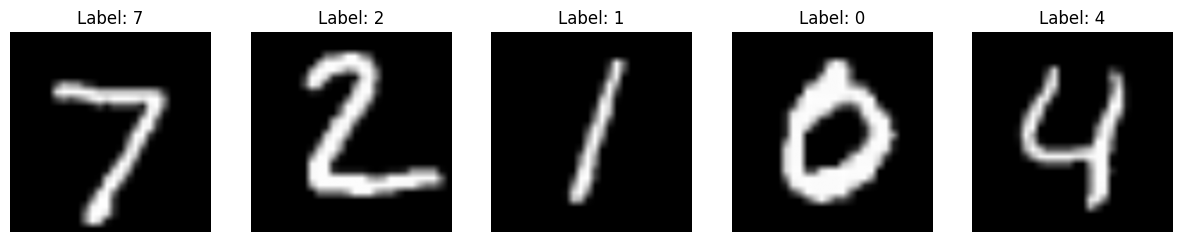

In [16]:
import matplotlib.pyplot as plt

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
# Get a batch of images and labels
dataiter = iter(testloader)
images, labels = next(dataiter)

# Plot the images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for idx in range(5):
    image = images[idx].numpy().transpose((1, 2, 0))
    image = image * 0.3081 + 0.1307  # Unnormalize
    axes[idx].imshow(image.squeeze(), cmap='gray')
    axes[idx].set_title(f'Label: {labels[idx].item()}')
    axes[idx].axis('off')

plt.show()

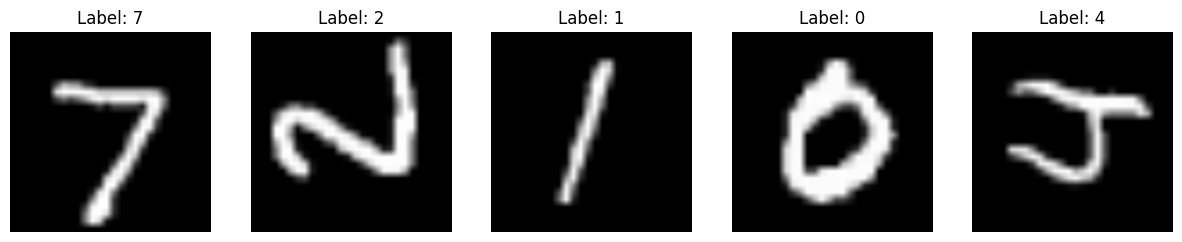

In [17]:
import matplotlib.pyplot as plt

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
testloader = random_rotate_dataset(testloader)
# Get a batch of images and labels
dataiter = iter(testloader)
images, labels = next(dataiter)

# Plot the images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for idx in range(5):
    image = images[idx].numpy().transpose((1, 2, 0))
    image = image * 0.3081 + 0.1307  # Unnormalize
    axes[idx].imshow(image.squeeze(), cmap='gray')
    axes[idx].set_title(f'Label: {labels[idx].item()}')
    axes[idx].axis('off')

plt.show()

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import random
from src import datasets

BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps")

trainset, testset = datasets.get_datasets("rotated_mnist", greyscale = False, image_size=None)

# Load MNIST
#trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

#testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
#testloader = random_rotate_dataset(testloader)

# Load ResNet model and modify first layer for MNIST (1-channel input)
model = resnet18(pretrained = True)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # Modify input layer
model.fc = nn.Linear(512, 10, bias=True)  # Modify output layer
model.load_state_dict(torch.load("resnet_mnist_99.14.pth"))
model = model.to(DEVICE)

average_evaluate()

/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/adamtsou/equivariant_spring2025/myenv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Test Accuracy: 9.07%


9.074

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [38]:
%pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [39]:
import torch
import torch.nn as nn
from torchvision.models import resnet18
from torchsummary import summary

# Define device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load ResNet-18 model
model = resnet18(weights=None).to(DEVICE)

# Print summary (assuming input size of 3x224x224 for ImageNet)
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [ ]:
def layer_average_evaluate():
    model.eval()
    correct, total = 0, 0
    angles = [0,90,180,270]
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = torch.zeros(inputs.size(0), 10).to(DEVICE)
            for angle in angles:
                rotated_inputs = torch.stack([transforms.functional.rotate(input, angle) for input in inputs])
                
                rotated_outputs = model.fc(x)
                outputs += rotated_outputs
            outputs = outputs / len(angles)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    acc = 100.0 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc

In [ ]:
def rotate_tensor(x, theta=math.pi/4):
    """Rotate input tensor in feature space using a 2D rotation matrix."""
    cos_theta = math.cos(theta)
    sin_theta = math.sin(theta)
    
    # Construct rotation matrix
    rot_matrix = torch.tensor([[cos_theta, -sin_theta], 
                               [sin_theta, cos_theta]], 
                              dtype=x.dtype, device=x.device)
    
    # Reshape input tensor for batch matrix multiplication
    B, C, H, W = x.shape
    x = x.view(B, C, -1)  # Flatten spatial dimensions
    
    # Apply rotation (assuming channel-wise pairing)
    if C % 2 == 0:  # Even number of channels
        x_rot = x.view(B, C//2, 2, -1)  # Group channels into pairs
        x_rot = torch.einsum('ij,bckj->bcki', rot_matrix, x_rot)  # Apply rotation
        x_rot = x_rot.view(B, C, -1)
    else:  # Odd channels, leave last channel unchanged
        x_main = x[:, :-1].view(B, (C-1)//2, 2, -1)
        x_main = torch.einsum('ij,bckj->bcki', rot_matrix, x_main)
        x_rot = torch.cat([x_main.view(B, C-1, -1), x[:, -1:]], dim=1)  # Append last channel back

    return x_rot.view(B, C, H, W)  # Reshape back to original


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18
import torchvision.transforms as transforms
import math
from collections import OrderedDict

def rotate_tensor(tensor, angle):
    # Check if MPS is being used
    if tensor.device.type == "mps":
        tensor = tensor.cpu()  # Move to CPU for rotation
        rotated_tensor = transforms.functional.rotate(tensor, angle)
        return rotated_tensor.to("mps")  # Move back to MPS
    else:
        return transforms.functional.rotate(tensor, angle)

class RotatedEmbeddingBlock(nn.Module):
    def __init__(self, original_block):
        super().__init__()
        # Define custom conv1 layer
        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # Custom input layer
        self.bn1 = original_block.bn1  # Use original batch norm
        self.relu = original_block.relu
        self.maxpool = original_block.maxpool

    def forward(self, x):
        
        
        angles = [0, 90, 180, 270]
        averaged_outputs = None

        for angle in angles:

            out = rotate_tensor(x, angle)
            out = self.conv1(out)  # Apply conv1
            out = rotate_tensor(out, -angle)
            if averaged_outputs is None:
                averaged_outputs = out
            else:
                averaged_outputs += out
    
        averaged_outputs = averaged_outputs / len(angles)

        x = self.bn1(averaged_outputs)
        x = self.relu(x)
        x = self.maxpool(x)
        averaged_outputs = None
        return x
    
class RotatedFCBlock(nn.Module):

    def __init__(self, original_block):
        super().__init__()
        self.avgpool = original_block.avgpool  
        self.fc = nn.Linear(512, 10,bias=True)  # Custom output layer      

    def forward(self, x):
        angles = [0, 90, 180, 270]

        averaged_outputs = None

        for angle in angles:
            out = rotate_tensor(x, angle)
            out = self.avgpool(out)
            out = torch.flatten(out, 1)
            out = self.fc(out)  
            out = rotate_tensor(out, -angle)

            if averaged_outputs is None:
                averaged_outputs = out
            else:
                averaged_outputs += out
            
        averaged_outputs = averaged_outputs / len(angles)

        return averaged_outputs


class RotatedBasicBlock(nn.Module):
            def __init__(self, original_block):
                super().__init__()
                self.conv1 = original_block.conv1
                self.bn1 = original_block.bn1
                self.relu = original_block.relu
                self.conv2 = original_block.conv2
                self.bn2 = original_block.bn2
                self.downsample = original_block.downsample

            def forward(self, x):
                angles = [0, 90, 180, 270]
                averaged_outputs = None

                for angle in angles:
                    # Rotate input
                    rotated_x = rotate_tensor(x, angle)

                    # First convolution
                    out = self.conv1(rotated_x)
                    out = self.bn1(out)
                    out = self.relu(out)

                    # Second convolution
                    out = self.conv2(out)
                    out = self.bn2(out)

                    # Handle downsample path
                    if self.downsample is not None:
                        identity = self.downsample(rotated_x)
                    else:
                        identity = rotated_x

                    # Add identity
                    out += identity

                    # Rotate back to original orientation
                    out = rotate_tensor(out, -angle)

                    # Accumulate outputs
                    if averaged_outputs is None:
                        averaged_outputs = out
                    else:
                        averaged_outputs += out

                # Average the outputs
                averaged_outputs = averaged_outputs / len(angles)

                return self.relu(averaged_outputs)

class RotatedResNet18(nn.Module):
    
    def __init__(self, num_classes=10):
        super().__init__()
        resnet = resnet18(weights=None)

        self.embedding = RotatedEmbeddingBlock(resnet)
        #self.embedding = nn.Sequential(
            #OrderedDict([('conv1', nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)), ('bn1', resnet.bn1), ('relu', resnet.relu), ('maxpool',resnet.maxpool)]))

        self.layer1 = nn.Sequential(*[RotatedBasicBlock(b) for b in resnet.layer1])
        #self.layer1 = resnet.layer1
        self.layer2 = nn.Sequential(*[RotatedBasicBlock(b) for b in resnet.layer2])
        #self.layer2 = resnet.layer2
        self.layer3 = nn.Sequential(*[RotatedBasicBlock(b) for b in resnet.layer3])
        #self.layer3 = resnet.layer3
        self.layer4 = nn.Sequential(*[RotatedBasicBlock(b) for b in resnet.layer4])
        #self.layer4 = resnet.layer4
        
        self.fc = RotatedFCBlock(resnet)
        

    def forward(self, x):
        x = self.embedding(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.fc(x)
        return x
    
# Load the model
model = RotatedResNet18(num_classes=10)

# Load state_dict
state_dict = torch.load("resnet_mnist_99.14.pth")

# Rename keys to match the RotatedResNet18 model
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith("conv1"):
        new_key = "embedding." + key  
    elif key.startswith("bn1"):
        new_key = "embedding." + key  
    elif key.startswith("fc"):
        new_key = "fc." + key        
    else:
        new_key = key
    new_state_dict[new_key] = value


model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [17]:
import torchvision
BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps")

# Data Augmentation & Normalization for MNIST
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet requires 224x224 input
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),  # MNIST Mean & Std
])
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

model.to(DEVICE)
model.eval()

RotatedResNet18(
  (embedding): RotatedEmbeddingBlock(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): RotatedBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): RotatedBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, a

In [18]:
def evaluate():
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    acc = 100.0 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc

evaluate()

RuntimeError: grid_sampler(): expected grid to have size 1 in last dimension, but got grid with sizes [1, 128, 10, 2]

In [4]:
import random 
class RotatedDataset(torch.utils.data.Dataset):
    def __init__(self, original_dataset, angles):
        self.original_dataset = original_dataset
        self.angles = angles
        # self.transform = transforms.Compose([
        #     transforms.ToPILImage(),
        # ])

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        img, label = self.original_dataset[idx]
        angle = random.choice(self.angles)
        # rotated_img = self.transform(img).rotate(angle)
        # rotated_img = transforms.ToTensor()(rotated_img)
        rotated_img = rotate_tensor(img, angle)
        return rotated_img, label
    
def rotate_tensor(tensor, angle):
    # pil_image = transforms.ToPILImage()(tensor)
    # rotated_image = pil_image.rotate(angle)
    # return transforms.ToTensor()(rotated_image)
    return transforms.functional.rotate(tensor, angle)

def random_rotate_dataset(dataloader, angles=[0, 90, 180, 270]):
    original_dataset = dataloader.dataset
    rotated_dataset = RotatedDataset(original_dataset, angles)
    return torch.utils.data.DataLoader(rotated_dataset, batch_size=dataloader.batch_size, shuffle=False, num_workers=0, pin_memory=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
testloader = random_rotate_dataset(testloader)

In [5]:
evaluate()

Test Accuracy: 9.58%


9.58

In [6]:
from src import datasets

BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps")

trainset, testset = datasets.get_datasets("rotated_mnist", greyscale = False, image_size=None)

# Load MNIST
#trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

#testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
#testloader = random_rotate_dataset(testloader)

In [7]:
evaluate()

Test Accuracy: 9.73%


9.728